# Chapter 13 — The Bigram Model: Predicting From One Previous Token

Chapter 12 used overall character frequencies but returned the same prediction for every context.

This chapter builds a **bigram model**, which changes its next-character probabilities according to the previous character.

By the end of this chapter, you should be able to:

- explain what a character bigram is;
- count adjacent character pairs;
- convert those counts into conditional probabilities;
- compare unigram and bigram predictions;
- generate text from a bigram model;
- measure both models on the training sequence;
- distinguish a missing-context fallback from smoothing; and
- explain why one-character context remains limited.

This chapter uses counting rather than neural networks.


## From Unigrams to Bigrams

A **bigram** is an adjacent pair of tokens.

At the character level, `cat` contains the bigrams `c → a` and `a → t`.

A unigram model asks how common each character is overall.

A bigram model instead asks which next characters were common **given** one previous character.

The notation $P(\text{next}=\text{"h"}\mid\text{previous}=\text{"T"})$ means the probability of `"h"` given that the previous character is `"T"`.

The vertical bar is read as “given.”


## Reuse the Prepared Character Fixture

The small fixture keeps every learned transition inspectable.

It includes repeated words, punctuation, spaces, and newlines.


In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print(repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Build Stable Character IDs

The sorted vocabulary gives every character a deterministic integer label.

The IDs are labels, while the character strings remain easier to use when inspecting counts.


In [2]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    prepared_text
)

print("Vocabulary size:", len(character_vocabulary))
for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>3}: {character!r}")

Vocabulary size: 22
  0: '\n'
  1: ' '
  2: '!'
  3: '.'
  4: 'T'
  5: 'a'
  6: 'b'
  7: 'c'
  8: 'd'
  9: 'e'
 10: 'g'
 11: 'h'
 12: 'i'
 13: 'k'
 14: 'l'
 15: 'n'
 16: 'o'
 17: 'r'
 18: 's'
 19: 't'
 20: 'w'
 21: 'y'


## Keep Encoding and Decoding Checkable

The exact round trip confirms that the token sequence preserves the fixture.


In [3]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    character_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        character_ids.append(character_to_id[character])
    return character_ids


def decode_character_ids(
    character_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []
    for position, character_id in enumerate(character_ids):
        if character_id not in id_to_character:
            raise ValueError(
                f"Unknown character ID {character_id} at position {position}."
            )
        characters.append(id_to_character[character_id])
    return "".join(characters)


training_token_ids = encode_characters(prepared_text, character_to_id)
decoded_training_text = decode_character_ids(training_token_ids, id_to_character)

assert decoded_training_text == prepared_text
print("Token count:", len(training_token_ids))
print("First 80 token IDs:", training_token_ids[:80])

Token count: 106
First 80 token IDs: [4, 11, 9, 1, 8, 16, 10, 1, 17, 5, 15, 1, 5, 7, 17, 16, 18, 18, 1, 19, 11, 9, 1, 21, 5, 17, 8, 3, 0, 4, 11, 9, 1, 7, 5, 19, 1, 18, 5, 19, 1, 15, 9, 5, 17, 1, 19, 11, 9, 1, 20, 12, 15, 8, 16, 20, 3, 0, 0, 4, 11, 9, 1, 8, 16, 10, 1, 14, 16, 16, 13, 9, 8, 1, 5, 19, 1, 19, 11, 9]


## Inspect Adjacent Pairs

Each neighboring pair is one observation of a previous character followed by a next character.


In [4]:
print("Position | Previous | Next")
print("-" * 28)
for position, (previous_character, next_character) in enumerate(
    zip(prepared_text[:-1], prepared_text[1:], strict=True)
):
    if position == 20:
        break
    print(f"{position:>8} | {previous_character!r:>8} | {next_character!r:>5}")

Position | Previous | Next
----------------------------
       0 |      'T' |   'h'
       1 |      'h' |   'e'
       2 |      'e' |   ' '
       3 |      ' ' |   'd'
       4 |      'd' |   'o'
       5 |      'o' |   'g'
       6 |      'g' |   ' '
       7 |      ' ' |   'r'
       8 |      'r' |   'a'
       9 |      'a' |   'n'
      10 |      'n' |   ' '
      11 |      ' ' |   'a'
      12 |      'a' |   'c'
      13 |      'c' |   'r'
      14 |      'r' |   'o'
      15 |      'o' |   's'
      16 |      's' |   's'
      17 |      's' |   ' '
      18 |      ' ' |   't'
      19 |      't' |   'h'


## Count Next Characters by Previous Character

A dictionary of `Counter` objects stores one next-character count table for each observed previous character.

The final text position supplies no pair because no character follows it.


In [5]:
from collections import Counter  # noqa: I001


def count_bigrams(text: str) -> dict[str, Counter[str]]:
    if len(text) < 2:
        raise ValueError("text must contain at least two characters.")

    counts_by_previous_character: dict[str, Counter[str]] = {}
    for previous_character, next_character in zip(text[:-1], text[1:], strict=True):
        if previous_character not in counts_by_previous_character:
            counts_by_previous_character[previous_character] = Counter()
        counts_by_previous_character[previous_character][next_character] += 1
    return counts_by_previous_character


bigram_counts = count_bigrams(prepared_text)

assert (
    sum(sum(counts.values()) for counts in bigram_counts.values())
    == len(prepared_text) - 1
)
print("Recorded bigrams:", len(prepared_text) - 1)
print("Previous-character entries:", len(bigram_counts))

Recorded bigrams: 105
Previous-character entries: 22


## Inspect Selected Count Distributions

Different previous characters produce different sets of observed next characters.


In [6]:
characters_to_inspect = ["T", "h", "e", " ", "c", ".", "\n"]

for previous_character in characters_to_inspect:
    print("Previous character:", repr(previous_character))
    next_counts = bigram_counts.get(previous_character)
    if next_counts is None:
        print("  no observed next characters")
    else:
        for next_character, count in next_counts.most_common():
            print(f"  {next_character!r:>6}: {count}")
    print()

Previous character: 'T'
     'h': 4

Previous character: 'h'
     'e': 7

Previous character: 'e'
     ' ': 7
     'd': 2
     'a': 1

Previous character: ' '
     't': 3
     'c': 3
     'd': 2
     'a': 2
     'l': 2
     'r': 1
     'y': 1
     's': 1
     'n': 1
     'w': 1
     'b': 1

Previous character: 'c'
     'a': 3
     'r': 1
     'k': 1

Previous character: '.'
    '\n': 2

Previous character: '\n'
     'T': 3
    '\n': 1



## Convert Counts Into Conditional Probabilities

For one previous character, divide each next-character count by that row's total count.

Unobserved next characters receive probability zero in this unsmoothed model.


In [7]:
def assert_valid_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")
    if any(probability < 0 for probability in probabilities):
        raise ValueError("Probabilities cannot be negative.")
    if abs(sum(probabilities) - 1.0) > 1e-12:
        raise ValueError("Probabilities must sum to 1.")


def counts_to_probabilities(
    vocabulary: list[str],
    token_counts: Counter[str],
) -> list[float]:
    total_count = sum(token_counts.values())
    if total_count <= 0:
        raise ValueError("token_counts must contain at least one observation.")
    probabilities = [token_counts[token] / total_count for token in vocabulary]
    assert_valid_probability_distribution(probabilities)
    return probabilities


probabilities_after_t = counts_to_probabilities(
    character_vocabulary,
    bigram_counts["T"],
)

for character, probability in zip(
    character_vocabulary, probabilities_after_t, strict=True
):
    if probability > 0:
        print(f"P({character!r} | 'T') = {probability:.6f}")

P('h' | 'T') = 1.000000


Every `"T"` in this fixture is followed by `"h"`, so the estimated probability is 1.

This is a statement about the tiny fixture rather than a universal rule of English.


## Build Every Bigram Distribution

Each dictionary value is a probability list aligned with the same character vocabulary.


In [8]:
def build_bigram_probabilities(
    vocabulary: list[str],
    counts_by_previous_character: dict[str, Counter[str]],
) -> dict[str, list[float]]:
    return {
        previous_character: counts_to_probabilities(vocabulary, next_counts)
        for previous_character, next_counts in counts_by_previous_character.items()
    }


bigram_probabilities = build_bigram_probabilities(
    character_vocabulary,
    bigram_counts,
)

for probabilities in bigram_probabilities.values():
    assert_valid_probability_distribution(probabilities)

print("Valid conditional distributions:", len(bigram_probabilities))

Valid conditional distributions: 22


## Plot One Conditional Distribution

The distribution after a space reveals which word-starting characters occur in the fixture.


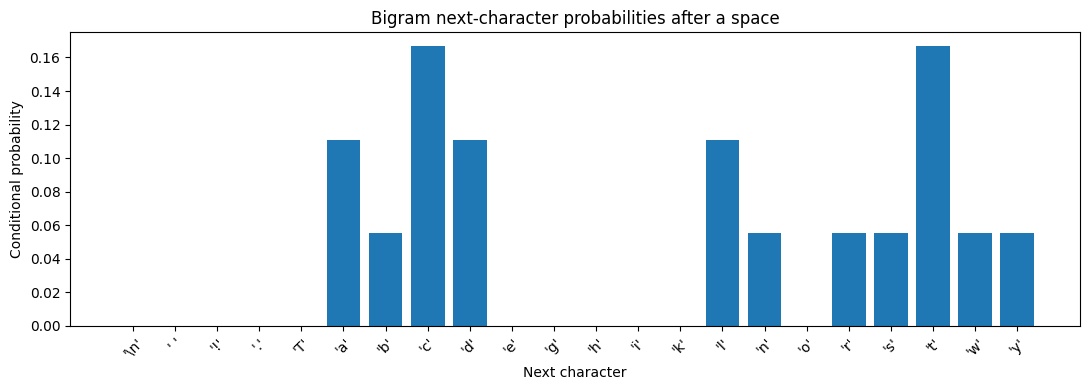

In [9]:
import matplotlib.pyplot as plt  # noqa: I001


probabilities_after_space = bigram_probabilities[" "]
labels = [repr(character) for character in character_vocabulary]

plt.figure(figsize=(11, 4))
plt.bar(labels, probabilities_after_space)
plt.xlabel("Next character")
plt.ylabel("Conditional probability")
plt.title("Bigram next-character probabilities after a space")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Compare Unigram and Bigram Predictions

The unigram distribution uses overall counts, while the bigram distribution after `"T"` uses only transitions leaving `"T"`.


In [10]:
unigram_counts = Counter(prepared_text)
unigram_probabilities = counts_to_probabilities(
    character_vocabulary,
    unigram_counts,
)

print("Character | Unigram | Bigram after 'T'")
print("-" * 39)
for character, unigram_probability, bigram_probability in zip(
    character_vocabulary,
    unigram_probabilities,
    probabilities_after_t,
    strict=True,
):
    print(
        f"{character!r:>9} | {unigram_probability:>7.4f} | {bigram_probability:>16.4f}"
    )

Character | Unigram | Bigram after 'T'
---------------------------------------
     '\n' |  0.0377 |           0.0000
      ' ' |  0.1698 |           0.0000
      '!' |  0.0094 |           0.0000
      '.' |  0.0283 |           0.0000
      'T' |  0.0377 |           0.0000
      'a' |  0.0943 |           0.0000
      'b' |  0.0094 |           0.0000
      'c' |  0.0472 |           0.0000
      'd' |  0.0566 |           0.0000
      'e' |  0.0943 |           0.0000
      'g' |  0.0189 |           0.0000
      'h' |  0.0660 |           1.0000
      'i' |  0.0094 |           0.0000
      'k' |  0.0283 |           0.0000
      'l' |  0.0189 |           0.0000
      'n' |  0.0283 |           0.0000
      'o' |  0.0755 |           0.0000
      'r' |  0.0377 |           0.0000
      's' |  0.0283 |           0.0000
      't' |  0.0755 |           0.0000
      'w' |  0.0189 |           0.0000
      'y' |  0.0094 |           0.0000


## Package the Bigram Model

The model reads only the final input token and returns the corresponding conditional distribution.

An empty input or a known character without outgoing counts uses unigram probabilities as a fallback.

This fallback chooses a complete distribution only when no conditional row exists.

It is not **smoothing**, because smoothing would modify every row to give positive probability to unseen transitions.


In [11]:
class BigramCharacterModel:
    def __init__(self, vocabulary: list[str], training_text: str):
        self.vocabulary = vocabulary
        self.fallback_probabilities = counts_to_probabilities(
            vocabulary,
            Counter(training_text),
        )
        self.bigram_counts = count_bigrams(training_text)
        self.bigram_probabilities = build_bigram_probabilities(
            vocabulary,
            self.bigram_counts,
        )

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
        id_to_character: dict[int, str],
    ) -> list[float]:
        if not input_token_ids:
            return self.fallback_probabilities

        previous_character = id_to_character[input_token_ids[-1]]
        return self.bigram_probabilities.get(
            previous_character,
            self.fallback_probabilities,
        )


bigram_model = BigramCharacterModel(character_vocabulary, prepared_text)

## Verify That Only the Final Character Matters

Contexts ending in the same character must receive identical bigram predictions.


In [12]:
def most_likely_character(
    probabilities: list[float],
    id_to_character: dict[int, str],
) -> tuple[str, float]:
    best_id = max(range(len(probabilities)), key=probabilities.__getitem__)
    return id_to_character[best_id], probabilities[best_id]


contexts = ["T", "Th", "The ", "The c", "dog c", "."]
for context in contexts:
    context_ids = encode_characters(context, character_to_id)
    probabilities = bigram_model.predict_next_token_probabilities(
        context_ids,
        id_to_character,
    )
    best_character, best_probability = most_likely_character(
        probabilities,
        id_to_character,
    )
    print(
        f"context {context!r:>7} uses {context[-1]!r}: "
        f"best next {best_character!r} at {best_probability:.3f}"
    )

the_c_probabilities = bigram_model.predict_next_token_probabilities(
    encode_characters("The c", character_to_id),
    id_to_character,
)
dog_c_probabilities = bigram_model.predict_next_token_probabilities(
    encode_characters("dog c", character_to_id),
    id_to_character,
)
assert the_c_probabilities == dog_c_probabilities

context     'T' uses 'T': best next 'h' at 1.000
context    'Th' uses 'h': best next 'e' at 1.000
context  'The ' uses ' ': best next 'c' at 0.167
context 'The c' uses 'c': best next 'a' at 0.600
context 'dog c' uses 'c': best next 'a' at 0.600
context     '.' uses '.': best next '\n' at 1.000


Both `"The c"` and `"dog c"` end in `"c"`, so the bigram model treats them as the same context.

Everything before the final character is ignored.


## Verify the Empty-Context Fallback

Without a previous character, the model returns its unigram fallback distribution.


In [13]:
empty_context_probabilities = bigram_model.predict_next_token_probabilities(
    [],
    id_to_character,
)

assert empty_context_probabilities == bigram_model.fallback_probabilities
assert_valid_probability_distribution(empty_context_probabilities)
print("Empty context uses unigram fallback:", True)

Empty context uses unigram fallback: True


## Generate From the Bigram Model

Generation repeatedly uses the newest character as context, samples one next character, and appends it.

A fixed seed keeps the stored output reproducible.


In [14]:
import random  # noqa: I001


RANDOM_SEED = 13


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    assert_valid_probability_distribution(probabilities)
    return random_generator.choices(
        range(len(probabilities)),
        weights=probabilities,
        k=1,
    )[0]


def generate_bigram_text(
    model: BigramCharacterModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    random_generator = random.Random(random_seed)
    generated_text = prompt
    for _ in range(number_of_new_characters):
        input_ids = encode_characters(generated_text, character_to_id)
        probabilities = model.predict_next_token_probabilities(
            input_ids,
            id_to_character,
        )
        next_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_id]
    return generated_text


bigram_generated_text = generate_bigram_text(
    bigram_model,
    prompt="T",
    number_of_new_characters=160,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)

print(bigram_generated_text)
print()
print(repr(bigram_generated_text))

The t cane lokedog batheathed.
The cathe log d candok.



Thed.
Thedoog the t s yat rdoke cat cat!

The yarat los d.
The athe ss nd car d t!
The car t t cacarath

'The t cane lokedog batheathed.\nThe cathe log d candok.\n\n\n\nThed.\nThedoog the t s yat rdoke cat cat!\n\nThe yarat los d.\nThe athe ss nd car d t!\nThe car t t cacarath'


The generated text contains plausible local fragments because every sampled transition was observed after its preceding character.

The result remains globally incoherent because one previous character cannot represent words, phrases, or sentences.


## Compare Generation With a Unigram Model

Using the same seed does not force identical samples because the two models supply different probability weights.


In [15]:
class UnigramCharacterModel:
    def __init__(self, vocabulary: list[str], training_text: str):
        self.probabilities = counts_to_probabilities(
            vocabulary,
            Counter(training_text),
        )

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        return self.probabilities


def generate_unigram_text(
    model: UnigramCharacterModel,
    prompt: str,
    number_of_new_characters: int,
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    random_generator = random.Random(random_seed)
    generated_text = prompt
    for _ in range(number_of_new_characters):
        probabilities = model.predict_next_token_probabilities([])
        next_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_id]
    return generated_text


unigram_model = UnigramCharacterModel(character_vocabulary, prepared_text)
unigram_generated_text = generate_unigram_text(
    unigram_model,
    prompt="T",
    number_of_new_characters=160,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)

print("Unigram sample:")
print(unigram_generated_text)
print()
print("Bigram sample:")
print(bigram_generated_text)

Unigram sample:
TTkkr . .n e!acrh
T sooontoTrdoecaca oowken id  eTdhc e.. a htclt  orh csso ral tgl!heganaa k . hee da 
y aTg dar
aetedha
etnTkrTga.a a c og
o deaad r o.ac
 adsw

Bigram sample:
The t cane lokedog batheathed.
The cathe log d candok.



Thed.
Thedoog the t s yat rdoke cat cat!

The yarat los d.
The athe ss nd car d t!
The car t t cacarath


The unigram sample reflects overall character frequency but ignores adjacency.

The bigram sample preserves observed local transitions, although a single sample is not a reliable model evaluation by itself.


## Measure Training-Sequence Loss

Average negative log-likelihood measures how much probability a model assigns to the actual next characters.

Lower loss is better because it means the observed targets received more probability.

The bigram model is evaluated only on observed training transitions here, so every target has nonzero probability.


In [16]:
import math
from collections.abc import Callable


def average_next_character_loss(
    text: str,
    probabilities_for_previous_character: Callable[[str], list[float]],
    character_to_id: dict[str, int],
) -> float:
    losses = []
    for previous_character, next_character in zip(text[:-1], text[1:], strict=True):
        probabilities = probabilities_for_previous_character(previous_character)
        target_id = character_to_id[next_character]
        target_probability = probabilities[target_id]
        if target_probability <= 0:
            return math.inf
        losses.append(-math.log(target_probability))
    return sum(losses) / len(losses)


unigram_loss = average_next_character_loss(
    prepared_text,
    lambda previous_character: unigram_model.probabilities,
    character_to_id,
)
bigram_loss = average_next_character_loss(
    prepared_text,
    lambda previous_character: bigram_model.bigram_probabilities[previous_character],
    character_to_id,
)

print("Unigram average training loss:", unigram_loss)
print("Bigram average training loss: ", bigram_loss)
print("Loss improvement:             ", unigram_loss - bigram_loss)
assert bigram_loss < unigram_loss

Unigram average training loss: 2.7933434359262477
Bigram average training loss:  1.0502225445346483
Loss improvement:              1.7431208913915994


The bigram loss is lower because the model conditions on information that the unigram model discards.

This training-set result does not prove that the model will generalize well to new text.

An unsmoothed bigram model can assign probability zero to an unseen transition, producing infinite loss on that transition.


## Inspect Learned Transitions

Readable transition summaries make this small count-based model easy to audit.


In [17]:
def print_top_next_characters(
    previous_character: str,
    counts_by_previous_character: dict[str, Counter[str]],
    max_items: int = 5,
) -> None:
    print("Previous character:", repr(previous_character))
    next_counts = counts_by_previous_character.get(previous_character)
    if next_counts is None:
        print("  no observed next characters")
        return

    total_count = sum(next_counts.values())
    for next_character, count in next_counts.most_common(max_items):
        print(
            f"  next {next_character!r:>6}: count {count:>2}, "
            f"probability {count / total_count:.3f}"
        )


for previous_character in ["T", "h", "e", " ", "a", "c", "o", "."]:
    print_top_next_characters(previous_character, bigram_counts)
    print()

Previous character: 'T'
  next    'h': count  4, probability 1.000

Previous character: 'h'
  next    'e': count  7, probability 1.000

Previous character: 'e'
  next    ' ': count  7, probability 0.700
  next    'd': count  2, probability 0.200
  next    'a': count  1, probability 0.100

Previous character: ' '
  next    't': count  3, probability 0.167
  next    'c': count  3, probability 0.167
  next    'd': count  2, probability 0.111
  next    'a': count  2, probability 0.111
  next    'l': count  2, probability 0.111

Previous character: 'a'
  next    't': count  5, probability 0.500
  next    'c': count  2, probability 0.200
  next    'r': count  2, probability 0.200
  next    'n': count  1, probability 0.100

Previous character: 'c'
  next    'a': count  3, probability 0.600
  next    'r': count  1, probability 0.200
  next    'k': count  1, probability 0.200

Previous character: 'o'
  next    'g': count  2, probability 0.250
  next    'o': count  2, probability 0.250
  next   

## Limitations and Common Mistakes

- A bigram model uses only one previous token, regardless of prompt length.

- Probability zero means a transition was absent from this training text, not impossible in real language.

- The final character occurrence creates no outgoing pair because nothing follows it.

- Counts from a tiny fixture can produce brittle probabilities based on very little evidence.

- Locally plausible transitions do not guarantee coherent words or sentences.

- A missing-context fallback is not smoothing.

- Generated text should be inspected with `repr` when spaces and newlines are otherwise hard to see.


## Takeaways

A bigram model counts adjacent token pairs and estimates a separate next-token distribution for each previous token.

It improves on a unigram model because its predictions change with local context.

Its central limitation is equally clear: everything except the final input token is ignored.

The next chapter will arrange these same counts in a table whose rows are previous tokens and whose columns are next tokens.

That table will connect count-based transitions to the matrix representations used later.
